In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

print("Shape:", X.shape)
print("Number of classes:", len(np.unique(y)))
X.head()

Shape: (178, 13)
Number of classes: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
X.info()
X.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Standardized. Checking first few rows:")
pd.DataFrame(X_scaled, columns=wine.feature_names).head()

Standardized. Checking first few rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [5]:
for n in [2, 3, 4, 5]:
    hc = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = hc.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    hom = homogeneity_score(y, labels)
    print(f"n_clusters={n} -> Silhouette: {sil:.4f}, Homogeneity: {hom:.4f}")

n_clusters=2 -> Silhouette: 0.2670, Homogeneity: 0.4441
n_clusters=3 -> Silhouette: 0.2774, Homogeneity: 0.7904
n_clusters=4 -> Silhouette: 0.2258, Homogeneity: 0.7904
n_clusters=5 -> Silhouette: 0.1867, Homogeneity: 0.8106


In [6]:
# Going with n=3 since the dataset has 3 wine types
hc3 = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc3_labels = hc3.fit_predict(X_scaled)

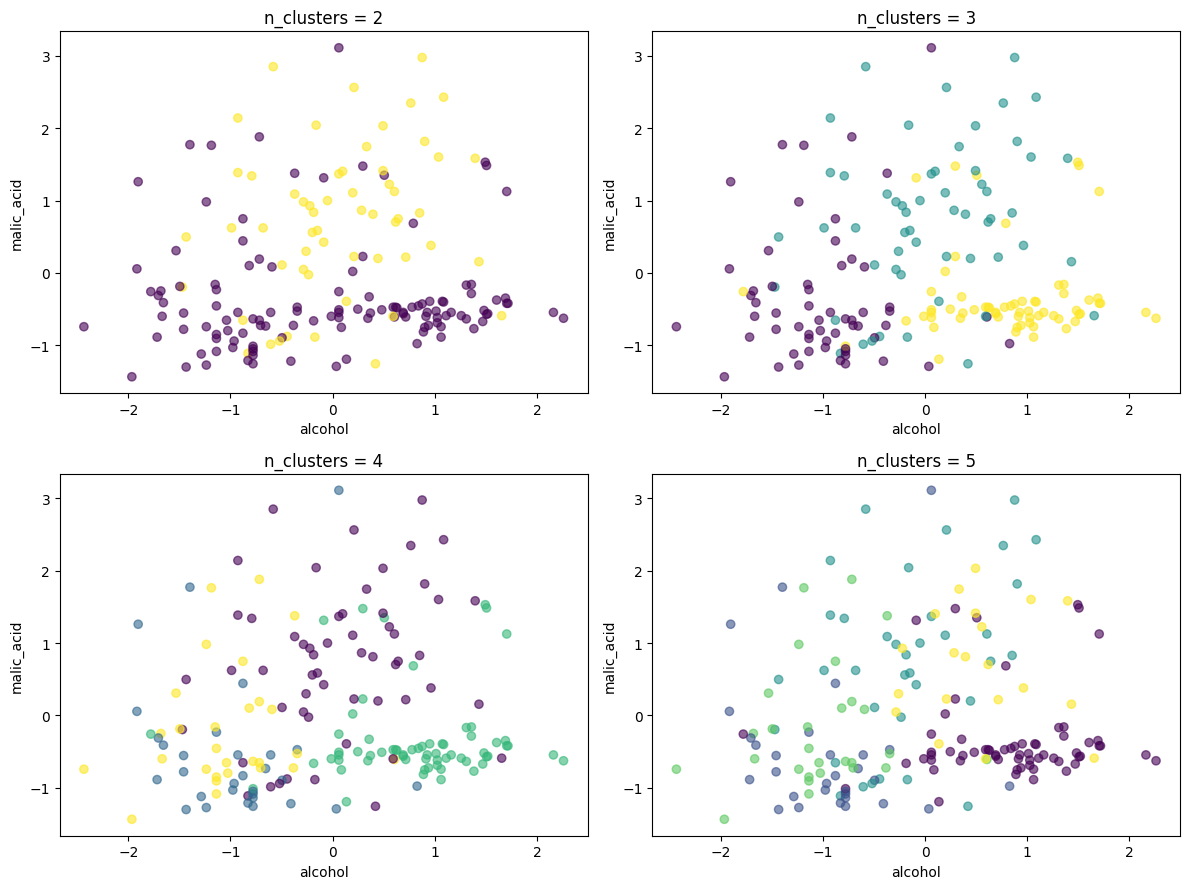

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for idx, n in enumerate([2, 3, 4, 5]):
    ax = axes[idx // 2][idx % 2]
    hc = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = hc.fit_predict(X_scaled)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', alpha=0.6)
    ax.set_title(f'n_clusters = {n}')
    ax.set_xlabel(wine.feature_names[0])
    ax.set_ylabel(wine.feature_names[1])
plt.tight_layout()
plt.show()

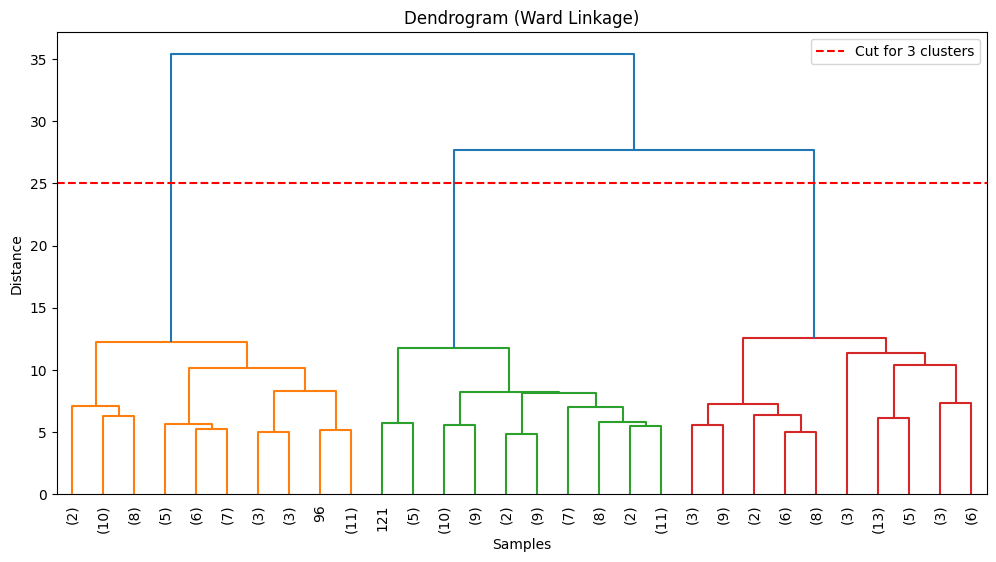

In [8]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Dendrogram (Ward Linkage)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.axhline(y=25, color='r', linestyle='--', label='Cut for 3 clusters')
plt.legend()
plt.show()

In [9]:
# Trying a few combinations
params = [(1.5, 5), (2.0, 5), (2.5, 5), (3.0, 5), (2.5, 3), (2.5, 7), (3.0, 10)]

for eps, ms in params:
    db = DBSCAN(eps=eps, min_samples=ms)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)
    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
        print(f"eps={eps}, min_samples={ms} -> clusters={n_clusters}, noise={noise}, silhouette={sil:.4f}")
    else:
        print(f"eps={eps}, min_samples={ms} -> clusters={n_clusters}, noise={noise}, (not enough clusters for silhouette)")

eps=1.5, min_samples=5 -> clusters=0, noise=178, (not enough clusters for silhouette)
eps=2.0, min_samples=5 -> clusters=5, noise=85, silhouette=-0.0329
eps=2.5, min_samples=5 -> clusters=1, noise=24, (not enough clusters for silhouette)
eps=3.0, min_samples=5 -> clusters=1, noise=11, (not enough clusters for silhouette)
eps=2.5, min_samples=3 -> clusters=1, noise=23, (not enough clusters for silhouette)
eps=2.5, min_samples=7 -> clusters=1, noise=29, (not enough clusters for silhouette)
eps=3.0, min_samples=10 -> clusters=1, noise=12, (not enough clusters for silhouette)


In [10]:
# eps=2.5, min_samples=5 seemed to give a decent result, going with that
db = DBSCAN(eps=2.5, min_samples=5)
db_labels = db.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_count = list(db_labels).count(-1)
print(f"Clusters: {n_clusters}, Noise points: {noise_count}")

Clusters: 1, Noise points: 24


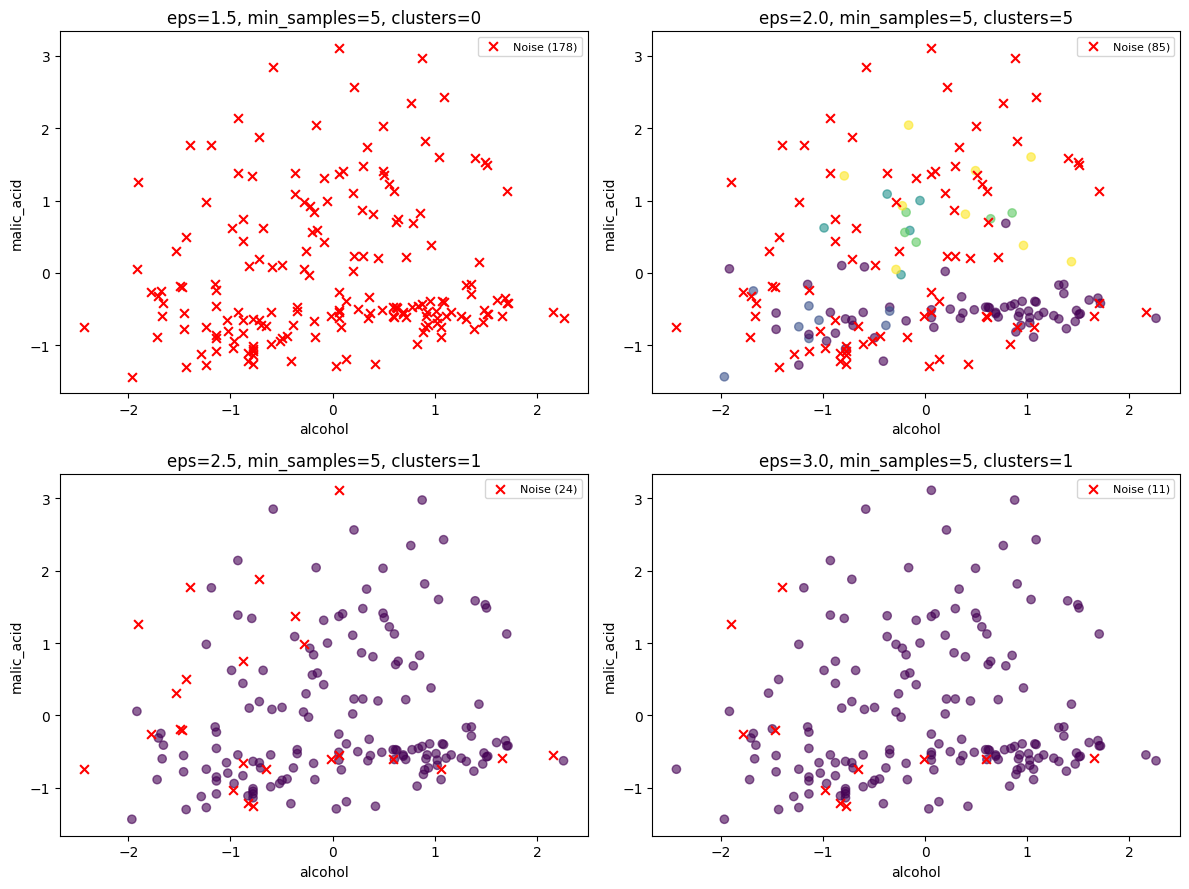

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
combos = [(1.5, 5), (2.0, 5), (2.5, 5), (3.0, 5)]

for idx, (eps, ms) in enumerate(combos):
    ax = axes[idx // 2][idx % 2]
    labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
    noise = labels == -1
    ax.scatter(X_scaled[~noise, 0], X_scaled[~noise, 1], c=labels[~noise], cmap='viridis', alpha=0.6)
    ax.scatter(X_scaled[noise, 0], X_scaled[noise, 1], c='red', marker='x', s=40, label=f'Noise ({noise.sum()})')
    n_c = len(set(labels)) - (1 if -1 in labels else 0)
    ax.set_title(f'eps={eps}, min_samples={ms}, clusters={n_c}')
    ax.set_xlabel(wine.feature_names[0])
    ax.set_ylabel(wine.feature_names[1])
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
mask = db_labels != -1
print("DBSCAN Evaluation Metrics:")
print(f"Silhouette Score: {silhouette_score(X_scaled, db_labels):.4f}")
if len(np.unique(db_labels[mask])) > 1:
    print(f"Homogeneity Score: {homogeneity_score(y[mask], db_labels[mask]):.4f}")
    print(f"Completeness Score: {completeness_score(y[mask], db_labels[mask]):.4f}")

DBSCAN Evaluation Metrics:
Silhouette Score: 0.1350


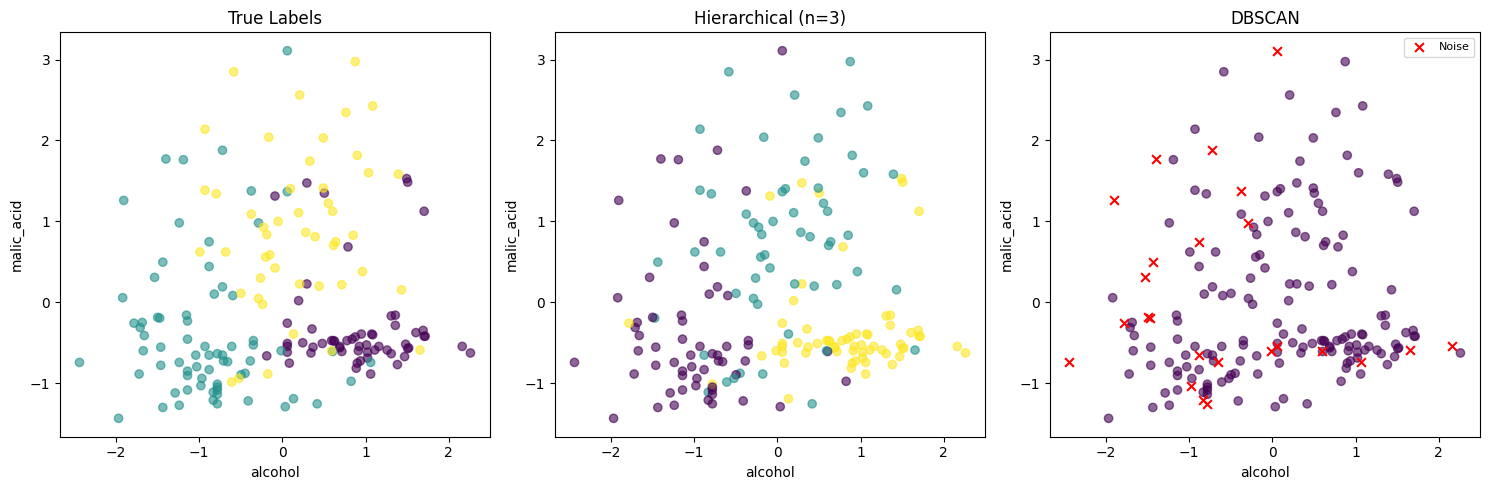

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# True labels
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', alpha=0.6)
axes[0].set_title('True Labels')

# Hierarchical
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=hc3_labels, cmap='viridis', alpha=0.6)
axes[1].set_title('Hierarchical (n=3)')

# DBSCAN
noise = db_labels == -1
axes[2].scatter(X_scaled[~noise, 0], X_scaled[~noise, 1], c=db_labels[~noise], cmap='viridis', alpha=0.6)
axes[2].scatter(X_scaled[noise, 0], X_scaled[noise, 1], c='red', marker='x', s=40, label='Noise')
axes[2].set_title('DBSCAN')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel(wine.feature_names[0])
    ax.set_ylabel(wine.feature_names[1])
plt.tight_layout()
plt.show()

In [14]:
print("Hierarchical (n=3):")
print(f"  Silhouette:   {silhouette_score(X_scaled, hc3_labels):.4f}")
print(f"  Homogeneity:  {homogeneity_score(y, hc3_labels):.4f}")
print(f"  Completeness: {completeness_score(y, hc3_labels):.4f}")

print("\nDBSCAN:")
print(f"  Silhouette:   {silhouette_score(X_scaled, db_labels):.4f}")
mask = db_labels != -1
if len(np.unique(db_labels[mask])) > 1:
    print(f"  Homogeneity:  {homogeneity_score(y[mask], db_labels[mask]):.4f}")
    print(f"  Completeness: {completeness_score(y[mask], db_labels[mask]):.4f}")

Hierarchical (n=3):
  Silhouette:   0.2774
  Homogeneity:  0.7904
  Completeness: 0.7825

DBSCAN:
  Silhouette:   0.1350
